This code is implementing and visualizing the Perceptron algorithm from scratch on a synthetic dataset. It trains a simple linear classifier and then plots the decision boundary that separates the two classes.

In [ ]:
from sklearn.datasets import make_classification
import numpy as np
#X → features (inputs)
#y -> label

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [3]:
print(X)


[[ 0.19924745 -0.11697552]
 [-0.24882029 -0.73115232]
 [-0.3544904  -0.7081059 ]
 [-1.59086506 -2.01199214]
 [-0.20083951  1.63493163]
 [-0.83241122  0.15599044]
 [-1.79207014  1.07782053]
 [ 0.0856607   0.80626713]
 [-0.55865299  0.74859527]
 [-1.95974262  0.75152794]
 [-1.77828947 -0.90114581]
 [-1.77985853 -0.1815243 ]
 [-0.02194151 -2.98092432]
 [ 0.80563431  1.20500136]
 [-1.82701214  0.78302407]
 [ 0.38730728  0.42968688]
 [-0.14108668 -0.73229726]
 [-1.87955941 -0.83930476]
 [-0.18232911  0.83727062]
 [-1.77059533 -0.10255323]
 [-2.27658028  0.65867001]
 [-2.06519502  0.92649819]
 [-1.31690551  0.10216193]
 [ 1.61043259  0.46886454]
 [-1.21650394  0.45432938]
 [ 0.6139723   1.8613386 ]
 [-1.78760957 -0.79255991]
 [-1.04149161 -1.0004391 ]
 [-2.40067584 -0.53814137]
 [-1.80383452  0.44027716]
 [-1.44075613  0.27047889]
 [ 1.34989978 -0.75869267]
 [ 0.22520167  0.6802322 ]
 [ 0.53688527  0.17018845]
 [ 0.55483459 -1.01121977]
 [-0.32178185 -0.8394709 ]
 [-0.98821248  0.90327412]
 

In [4]:
print(y)

[1 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 1 0
 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0
 1 1 0 1 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1]


In [5]:
import matplotlib.pyplot as plt

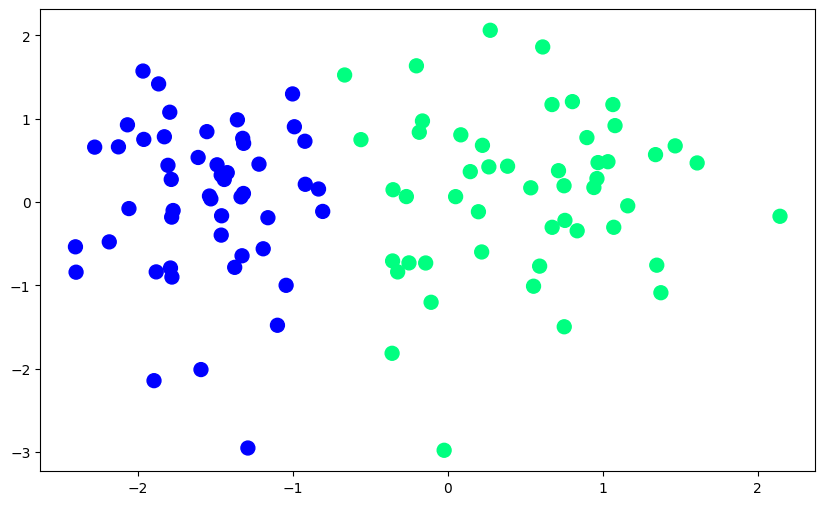

In [15]:
plt.figure(figsize=(10,6))
# x axis --> first feature
# y axis--> second feature
# cmap --> winter meaning which color style to use, winter meaning color combination of green and blue
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [ ]:

# The perceptron is one of the earliest machine learning algorithms and is basically a linear classifier.
# y=step(w1​x1​+w2​x2​+b)
def perceptron(X,y):
    #Add Bias Term- This inserts a column of 1s in front of the feature matrix.
    X = np.insert(X,0,1,axis=1)
    # Initialize Weights-> now there are 3 columns
    weights = np.ones(X.shape[1])
    #initialise learning rate
    lr = 0.1
    #epoch=20
    for i in range(50):
        #Each iteration randomly picks a sample.
        j = np.random.randint(0,100)
        #z=w0​+w1​x1​+w2​x2​ && passing through a step function which gives if its 0 or 1
        y_hat = step(np.dot(X[j],weights))
        # w=w+η(y−y^​)x
        # y=true label && lr==learning rate, X= input labels, y_hat= predicted label
        weights = weights + lr*(y[j]-y_hat)*X[j]

    # returns coffiencient(weights) && bias    
    return weights[0],weights[1:]


In [25]:
def step(z):
    return 1 if z>0 else 0

In [26]:
intercept_,coef_ = perceptron(X,y)

In [27]:
print(coef_)
print(intercept_)

[1.35862308 0.46269266]
0.8


In [28]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [29]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

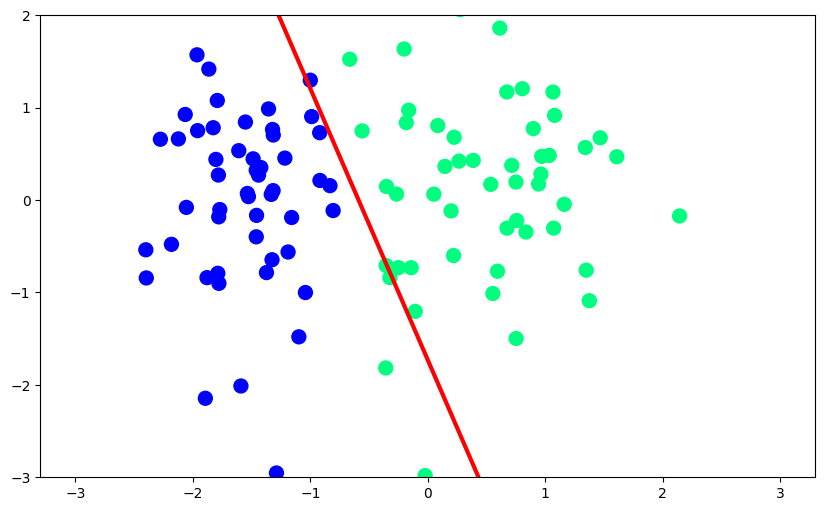

In [30]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)